# Sweep analysis: layers × seeds (llama vs apertus)

This notebook parses the logs produced by `clariden/train_multirun.sbatch` and builds a simple experiment analysis:
- collect runs (name, model, layer, seed, W&B run id/url),
- compare key metrics (`F1`, `AUC`, `accuracy`),
- plot metrics against layer (averaged across seeds, split by model),
- provide loss plotting helpers (from logs and optional W&B history).

In [1]:
import re
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)

In [2]:
RUN_RE = re.compile(r"(?P<model>llama|apertus)_no_lora_long_form_layer(?P<layer>\d+)_seed(?P<seed>\d+)")
SYNC_RE = re.compile(r"wandb:\s+Syncing run\s+(?P<run_name>\S+)")
URL_RE = re.compile(r"wandb:\s+🚀 View run at\s+(?P<url>https://\S+/runs/(?P<run_id>[a-zA-Z0-9]+))")
METRIC_RE = re.compile(
    r"wandb:\s+(?P<metric>train/longfact_test_(?:llama|apertus)/(?:span|max_|all_|span_)?(?:max_)?(?:accuracy|auc|f1)|train/longfact_test_(?:llama|apertus)/(?:span_max_accuracy|span_max_auc|span_max_f1|span_accuracy|span_auc|span_f1|all_accuracy|all_auc|all_f1)|train/loss)\s+(?P<value>-?\d+(?:\.\d+)?)"
)


def parse_run_name(run_name: str) -> dict:
    match = RUN_RE.search(run_name)
    if not match:
        return {"model": None, "layer": np.nan, "seed": np.nan}
    return {
        "model": match.group("model"),
        "layer": int(match.group("layer")),
        "seed": int(match.group("seed")),
    }


def _extract_run_records(err_text: str) -> list[dict]:
    records = []
    pending_names = []

    for line in err_text.splitlines():
        sync_match = SYNC_RE.search(line)
        if sync_match:
            run_name = sync_match.group("run_name")
            pending_names.append(run_name)
            continue

        url_match = URL_RE.search(line)
        if url_match and pending_names:
            run_name = pending_names.pop(0)
            parsed = parse_run_name(run_name)
            records.append(
                {
                    "run_name": run_name,
                    "run_id": url_match.group("run_id"),
                    "run_url": url_match.group("url"),
                    "model": parsed["model"],
                    "layer": parsed["layer"],
                    "seed": parsed["seed"],
                }
            )

    return records


def _extract_metrics_from_err_text(err_text: str) -> dict[str, float]:
    metrics = {}
    for match in METRIC_RE.finditer(err_text):
        metrics[match.group("metric")] = float(match.group("value"))
    return metrics


def parse_even_layer_err_file(err_path: Path) -> pd.DataFrame:
    text = err_path.read_text(errors="replace")
    records = _extract_run_records(text)
    if not records:
        return pd.DataFrame()

    out = pd.DataFrame(records)
    out["source_err"] = str(err_path)

    fallback_metrics = _extract_metrics_from_err_text(text)
    if fallback_metrics:
        for key, value in fallback_metrics.items():
            out[f"fallback::{key}"] = value

    return out


def fetch_wandb_run_summaries(
    runs_df: pd.DataFrame,
    entity: str = "ethz-lsai-25",
    project: str = "hallucination-probes",
) -> pd.DataFrame:
    try:
        import wandb
    except ImportError:
        return pd.DataFrame()

    api = wandb.Api()
    rows = []
    unique_runs = runs_df.dropna(subset=["run_id"]).drop_duplicates(subset=["run_id"])

    for _, run in unique_runs.iterrows():
        run_id = run["run_id"]
        run_path = f"{entity}/{project}/{run_id}"
        try:
            api_run = api.run(run_path)
            summary = dict(api_run.summary._json_dict)

            row = {
                "run_id": run_id,
                "wandb_name": api_run.name,
                "wandb_state": api_run.state,
            }
            for key, value in summary.items():
                if isinstance(value, (int, float)) and not str(key).startswith("_"):
                    row[str(key)] = float(value)
            rows.append(row)
        except Exception as exc:
            print(f"Failed to fetch {run_path}: {exc}")

    return pd.DataFrame(rows) if rows else pd.DataFrame()


def collect_even_layer_runs(
    log_dir: str | Path = "../clariden/log",
    enrich_from_wandb: bool = True,
    entity: str = "ethz-lsai-25",
    project: str = "hallucination-probes",
) -> pd.DataFrame:
    log_dir = Path(log_dir)
    err_files = sorted(log_dir.glob("even-layer-seeds-*.err"))
    parts = [parse_even_layer_err_file(path) for path in err_files]
    parts = [part for part in parts if not part.empty]
    if not parts:
        return pd.DataFrame()

    runs_df = pd.concat(parts, ignore_index=True)
    runs_df = runs_df.drop_duplicates(subset=["run_name", "run_id", "source_err"], keep="last")

    if enrich_from_wandb:
        wandb_summary_df = fetch_wandb_run_summaries(runs_df, entity=entity, project=project)
        if not wandb_summary_df.empty:
            runs_df = runs_df.merge(wandb_summary_df, on="run_id", how="left")
            fallback_cols = [col for col in runs_df.columns if col.startswith("fallback::train/")]
            for fallback_col in fallback_cols:
                metric_col = fallback_col.replace("fallback::", "")
                if metric_col not in runs_df.columns:
                    runs_df[metric_col] = runs_df[fallback_col]
                else:
                    runs_df[metric_col] = runs_df[metric_col].fillna(runs_df[fallback_col])

    metric_cols = [col for col in runs_df.columns if col.startswith("train/")]
    id_cols = [col for col in runs_df.columns if not col.startswith("train/")]
    runs_df = runs_df[id_cols + sorted(metric_cols)]
    return runs_df

In [42]:
MODEL_COLORS = {"apertus": "#E07B39", "llama": "#3B82C4"}
MODEL_LABELS = {"apertus": "Apertus", "llama": "Llama"}


def _style_axis(ax):
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.spines[["top", "right"]].set_visible(False)


def summarize_coverage(runs_df: pd.DataFrame) -> pd.DataFrame:
    if runs_df.empty:
        return pd.DataFrame()
    summary = (
        runs_df.groupby(["model", "layer"], as_index=False)
        .agg(n_seeds=("seed", "nunique"), runs=("run_name", "nunique"))
        .sort_values(["model", "layer"])
)
    return summary


def metric_mean_by_layer(
    runs_df: pd.DataFrame,
    metric_key: str,
    min_seeds: int = 1,
    aggregate_across_seeds: bool = True,
) -> pd.DataFrame:
    required_cols = {"model", "layer", "seed", metric_key}
    missing = [c for c in required_cols if c not in runs_df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    data = runs_df.dropna(subset=[metric_key, "model", "layer", "seed"]).copy()
    if data.empty:
        return pd.DataFrame()

    if not aggregate_across_seeds:
        return data[["model", "layer", "seed", metric_key]].sort_values(["model", "layer", "seed"])

    grouped = (
        data.groupby(["model", "layer"], as_index=False)
        .agg(
            mean=(metric_key, "mean"),
            std=(metric_key, "std"),
            n_seeds=("seed", "nunique"),
        )
        .query("n_seeds >= @min_seeds")
        .sort_values(["model", "layer"])
)
    grouped["std"] = grouped["std"].fillna(0.0)
    return grouped


def plot_metric_vs_layer(
    runs_df: pd.DataFrame,
    metric_key: str,
    title: str | None = None,
    min_seeds: int = 1,
    figsize: tuple[int, int] = (8, 4),
):
    agg = metric_mean_by_layer(runs_df, metric_key=metric_key, min_seeds=min_seeds, aggregate_across_seeds=True)
    if agg.empty:
        print(f"No data found for metric: {metric_key}")
        return

    fig, ax = plt.subplots(figsize=figsize)
    for model in ["apertus", "llama"]:
        model_df = agg[agg["model"] == model]
        if model_df.empty:
            continue
        color = MODEL_COLORS.get(model, None)
        label = MODEL_LABELS.get(model, model)
        ax.plot(model_df["layer"], model_df["mean"], marker="o", linewidth=2.2, color=color, label=label)
        ax.fill_between(
            model_df["layer"],
            model_df["mean"] - model_df["std"],
            model_df["mean"] + model_df["std"],
            color=color,
            alpha=0.18,
        )

    _style_axis(ax)
    ax.set_xlabel("Layer", fontsize=11)
    ax.set_ylabel(metric_key, fontsize=11)
    ax.set_title(title or f"{metric_key} vs layer", fontsize=12, pad=8)

    legend_handles = [
        plt.Line2D([0], [0], color=MODEL_COLORS["apertus"], marker="o", lw=2, label="Apertus"),
        plt.Line2D([0], [0], color=MODEL_COLORS["llama"], marker="o", lw=2, label="Llama"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=len(legend_handles),
        frameon=True,
        framealpha=0.85,
        fontsize=10,
        columnspacing=1.2,
        handletextpad=0.5,
    )

    fig.suptitle(r"$\bf{Layer\ Sweep\ Performance}$", y=1.02, fontsize=12)
    fig.text(
        0.5,
        -0.02,
        "Solid lines are means across seeds; shaded bands indicate ±1 standard deviation.",
        ha="center",
        fontsize=9,
        style="italic",
        color="gray",
    )
    fig.tight_layout()
    plt.show()


def plot_core_metrics_vs_layer(
    runs_df: pd.DataFrame,
    eval_target: str = "longfact_test_llama",
    family: str = "span_max",
):
    metric_map = {
        "F1": f"train/{eval_target}/{family}_f1",
        "AUC": f"train/{eval_target}/{family}_auc",
        "Accuracy": f"train/{eval_target}/{family}_accuracy",
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
    for axis, (label, metric_key) in zip(axes, metric_map.items()):
        agg = metric_mean_by_layer(runs_df, metric_key=metric_key)
        if agg.empty:
            axis.set_title(f"{label} (missing)", fontsize=11)
            _style_axis(axis)
            continue

        for model in ["apertus", "llama"]:
            model_df = agg[agg["model"] == model]
            if model_df.empty:
                continue
            color = MODEL_COLORS.get(model, None)
            pretty = MODEL_LABELS.get(model, model)
            axis.plot(model_df["layer"], model_df["mean"], marker="o", linewidth=2.0, color=color, label=pretty)
            axis.fill_between(
                model_df["layer"],
                model_df["mean"] - model_df["std"],
                model_df["mean"] + model_df["std"],
                color=color,
                alpha=0.16,
            )

        _style_axis(axis)
        axis.set_title(label, fontsize=11, pad=6)
        axis.set_xlabel("Layer", fontsize=10)
        axis.set_ylabel(label, fontsize=10)

    pretty_target = eval_target.replace("longfact_test_", "").replace("_", " ").title()
    pretty_family = family.replace("_", " ").title()

    legend_handles = [
        plt.Line2D([0], [0], color=MODEL_COLORS["apertus"], marker="o", lw=2, label="Apertus"),
        plt.Line2D([0], [0], color=MODEL_COLORS["llama"], marker="o", lw=2, label="Llama"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        ncol=len(legend_handles),
        frameon=True,
        framealpha=0.85,
        fontsize=10,
        columnspacing=1.2,
        handletextpad=0.5,
    )

    fig.suptitle(rf"$\bf{{Performance\ of\ linear\ probes\ trained\ on\ different\ layers\ training\ data\ from:\ {pretty_target}}}$", y=1.10, fontsize=12)
    fig.text(
        0.5,
        1.02,
        f"Metric family: {pretty_family}; each point is the mean across seeds. No LoRA",
        ha="center",
        fontsize=11,
    )
    fig.text(
        0.5,
        -0.04,
        "Shaded bands show ±1 standard deviation across seeds.",
        ha="center",
        fontsize=9,
        style="italic",
        color="gray",
    )
    fig.tight_layout()
    plt.show()


def plot_loss_vs_layer(
    runs_df: pd.DataFrame,
    loss_key: str = "train/loss",
 ):
    plot_metric_vs_layer(
        runs_df=runs_df,
        metric_key=loss_key,
        title="Final train/loss vs layer",
    )

In [43]:
def fetch_wandb_loss_history(
    runs_df: pd.DataFrame,
    entity: str = "ethz-lsai-25",
    project: str = "hallucination-probes",
    metric_key: str = "train/loss",
    max_rows_per_run: int | None = None,
) -> pd.DataFrame:
    try:
        import wandb
    except ImportError as exc:
        raise ImportError("wandb is required for history fetch. Install it in the kernel first.") from exc

    api = wandb.Api()
    rows = []
    for _, run in runs_df.dropna(subset=["run_id"]).iterrows():
        run_path = f"{entity}/{project}/{run['run_id']}"
        try:
            api_run = api.run(run_path)
            hist = api_run.history(keys=["_step", metric_key], pandas=True)
            if max_rows_per_run is not None:
                hist = hist.tail(max_rows_per_run)
            if hist.empty or metric_key not in hist.columns:
                continue
            hist = hist.dropna(subset=[metric_key])
            if hist.empty:
                continue
            hist["run_id"] = run["run_id"]
            hist["run_name"] = run["run_name"]
            hist["model"] = run["model"]
            hist["layer"] = run["layer"]
            hist["seed"] = run["seed"]
            rows.append(hist[["_step", metric_key, "run_id", "run_name", "model", "layer", "seed"]])
        except Exception as exc:
            print(f"Skipping {run_path}: {exc}")

    if not rows:
        return pd.DataFrame(columns=["_step", metric_key, "run_id", "run_name", "model", "layer", "seed"])
    return pd.concat(rows, ignore_index=True)


def _ema_smooth(values: np.ndarray, weight: float = 0.95) -> np.ndarray:
    if len(values) == 0:
        return values
    smoothed = np.zeros_like(values, dtype=float)
    last = float(values[0])
    for i, value in enumerate(values):
        last = last * weight + float(value) * (1 - weight)
        smoothed[i] = last
    return smoothed


def plot_loss_curves_from_history(
    history_df: pd.DataFrame,
    metric_key: str = "train/loss",
    model: str | None = None,
    layer: int | None = None,
    ema_weight: float = 0.95,
):
    if history_df.empty:
        print("No history data available.")
        return

    data = history_df.copy()
    if model is not None:
        data = data[data["model"] == model]
    if layer is not None:
        data = data[data["layer"] == layer]
    if data.empty:
        print("No history data after filtering.")
        return

    fig, ax = plt.subplots(figsize=(10, 5.5))
    groups = list(data.groupby(["run_name", "model", "layer", "seed"]))
    for run_key, run_df in groups:
        run_name, run_model, run_layer, run_seed = run_key
        run_df = run_df.sort_values("_step")
        color = MODEL_COLORS.get(run_model, None)
        y_raw = run_df[metric_key].to_numpy(dtype=float)
        x = run_df["_step"].to_numpy()

        ax.plot(x, y_raw, color=color, alpha=0.16, linewidth=0.9)
        ax.plot(
            x,
            _ema_smooth(y_raw, weight=ema_weight),
            color=color,
            linewidth=1.8,
            alpha=0.95,
            label=f"{MODEL_LABELS.get(run_model, run_model)} | L{run_layer} | s{run_seed}",
        )

    _style_axis(ax)
    ax.set_xlabel("Step", fontsize=10)
    ax.set_ylabel("Training Loss", fontsize=10)
    ax.set_title("Training loss curves from W&B history", fontsize=12, pad=8)

    if len(groups) <= 12:
        ax.legend(loc="upper right", framealpha=0.85, fontsize=8, ncol=2, title="Run")
    else:
        from matplotlib.lines import Line2D
        legend_handles = [
            Line2D([0], [0], color=MODEL_COLORS["apertus"], lw=2.2, label="Apertus"),
            Line2D([0], [0], color=MODEL_COLORS["llama"], lw=2.2, label="Llama"),
        ]
        ax.legend(handles=legend_handles, loc="upper right", framealpha=0.85, fontsize=9, title="Training model")

    fig.suptitle(r"$\bf{Cross\mbox{-}Entropy\ Training\ Loss}$", y=1.03, fontsize=12)
    fig.text(
        0.5,
        -0.03,
        f"Bold lines show EMA-smoothed trajectories (α={ema_weight}); faint lines show raw per-step values.",
        ha="center",
        fontsize=9,
        style="italic",
        color="gray",
    )
    fig.tight_layout()
    plt.show()

In [44]:
# Collect sweep runs from even-layer-seeds logs
runs_df = collect_even_layer_runs(log_dir="../clariden/log")
print(f"Parsed runs: {len(runs_df)}")
display(runs_df[["run_name", "run_id", "model", "layer", "seed", "source_err"]].sort_values(["model", "layer", "seed"]).head(20))

coverage_df = summarize_coverage(runs_df)
print("Coverage by model/layer:")
display(coverage_df)

# Quick completeness check against expected grid
expected_models = ["llama", "apertus"]
expected_layers = [4, 10, 16, 20, 24, 26, 28, 30]
expected_seeds = [42, 43, 44]
expected = pd.MultiIndex.from_product([expected_models, expected_layers, expected_seeds], names=["model", "layer", "seed"])
observed = pd.MultiIndex.from_frame(runs_df[["model", "layer", "seed"]].dropna().drop_duplicates())
missing = expected.difference(observed)
print(f"Expected runs: {len(expected)} | Observed unique runs: {len(observed)} | Missing: {len(missing)}")
if len(missing):
    display(pd.DataFrame(missing.tolist(), columns=["model", "layer", "seed"]))

Parsed runs: 48


,run_name,run_id,model,layer,seed,source_err
31,apertus_no_lora_long_form_layer4_seed42,f1osa4x3,apertus,4,42,../clariden/log/even-layer-seeds-1593546_6.err
29,apertus_no_lora_long_form_layer4_seed43,k9210t28,apertus,4,43,../clariden/log/even-layer-seeds-1593546_6.err
28,apertus_no_lora_long_form_layer4_seed44,4dw0ohsb,apertus,4,44,../clariden/log/even-layer-seeds-1593546_6.err
30,apertus_no_lora_long_form_layer10_seed42,2msk68xv,apertus,10,42,../clariden/log/even-layer-seeds-1593546_6.err
33,apertus_no_lora_long_form_layer10_seed43,ennpfi5c,apertus,10,43,../clariden/log/even-layer-seeds-1593549_7.err
32,apertus_no_lora_long_form_layer10_seed44,ckfvtpqq,apertus,10,44,../clariden/log/even-layer-seeds-1593549_7.err
35,apertus_no_lora_long_form_layer16_seed42,98q6shel,apertus,16,42,../clariden/log/even-layer-seeds-1593549_7.err
34,apertus_no_lora_long_form_layer16_seed43,92fyxrb6,apertus,16,43,../clariden/log/even-layer-seeds-1593549_7.err
37,apertus_no_lora_long_form_layer16_seed44,i19xd1q5,apertus,16,44,../clariden/log/even-layer-seeds-1593554_8.err
36,apertus_no_lora_long_form_layer20_seed42,5w54hojz,apertus,20,42,../clariden/log/even-layer-seeds-1593554_8.err


Coverage by model/layer:


,model,layer,n_seeds,runs
0,apertus,4,3,3
1,apertus,10,3,3
2,apertus,16,3,3
3,apertus,20,3,3
4,apertus,24,3,3
5,apertus,26,3,3
6,apertus,28,3,3
7,apertus,30,3,3
8,llama,4,3,3
9,llama,10,3,3


Expected runs: 48 | Observed unique runs: 48 | Missing: 0


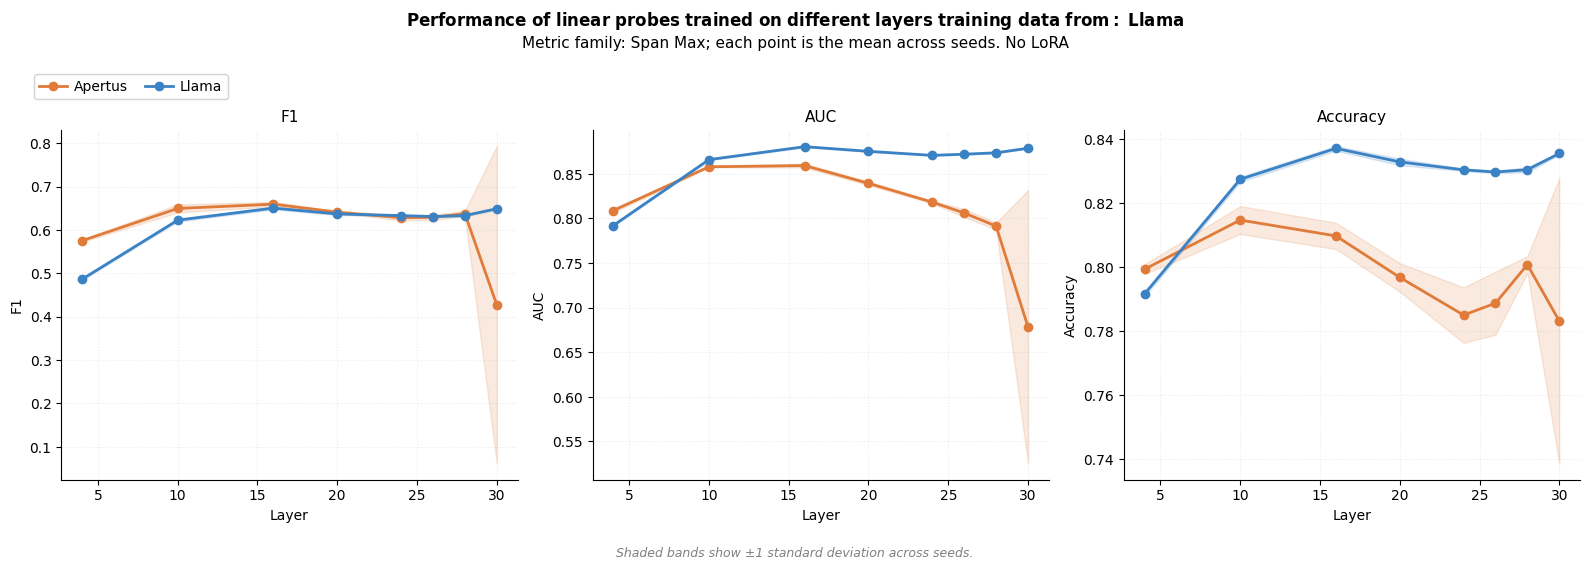

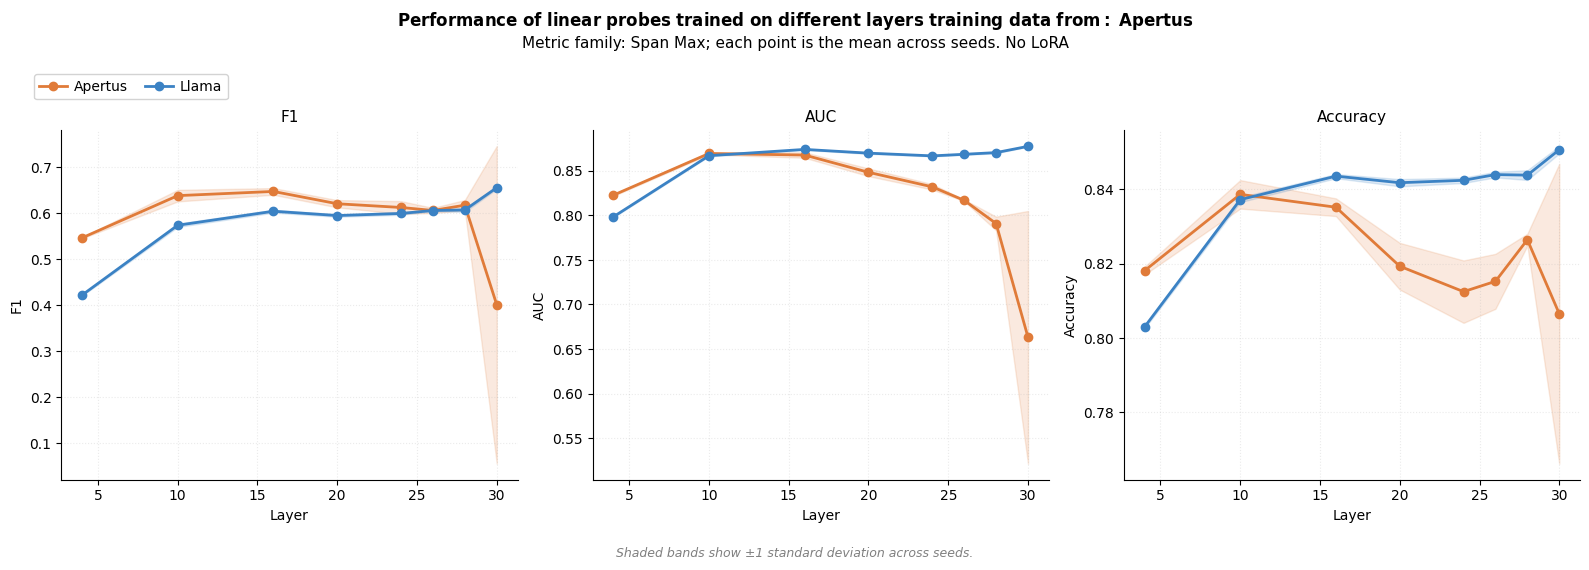

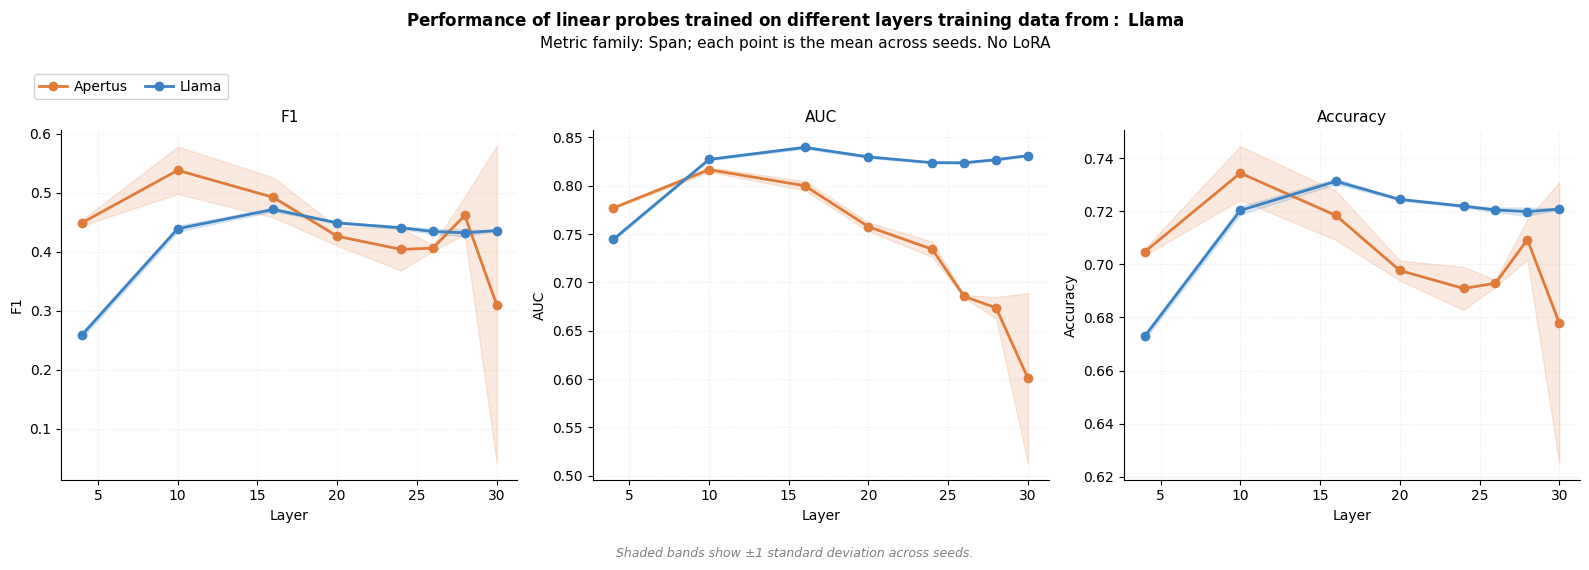

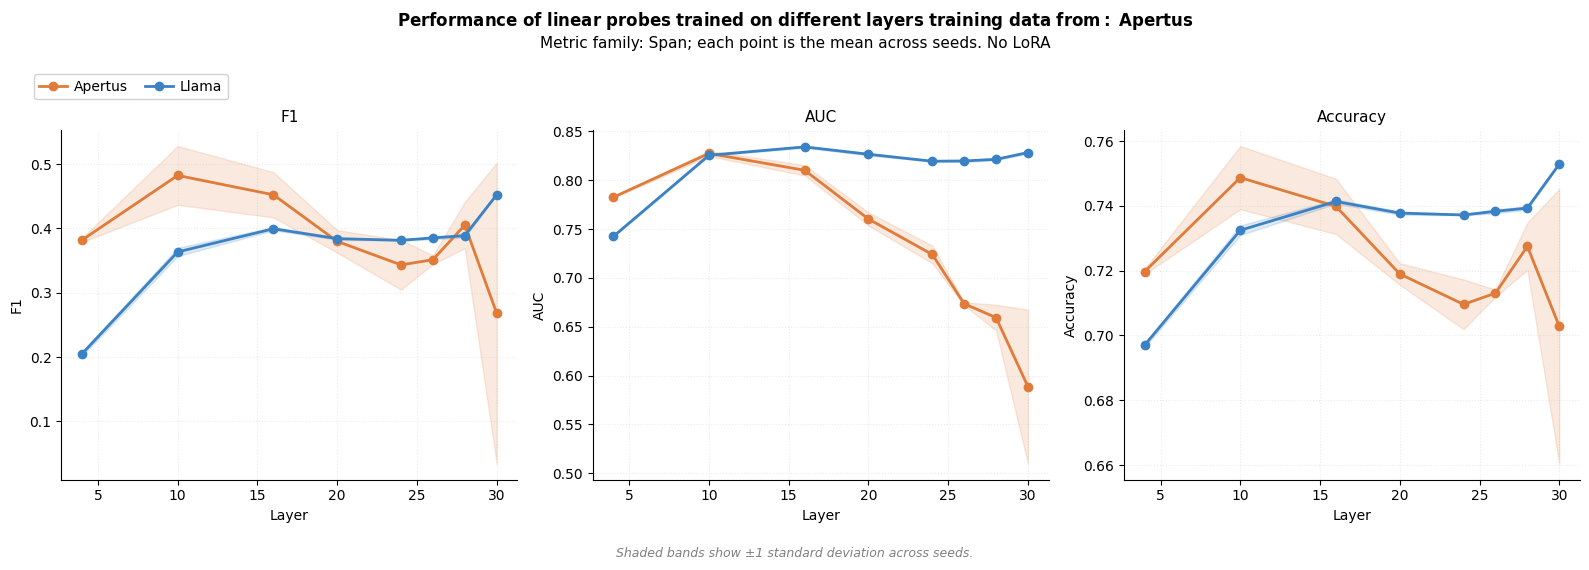

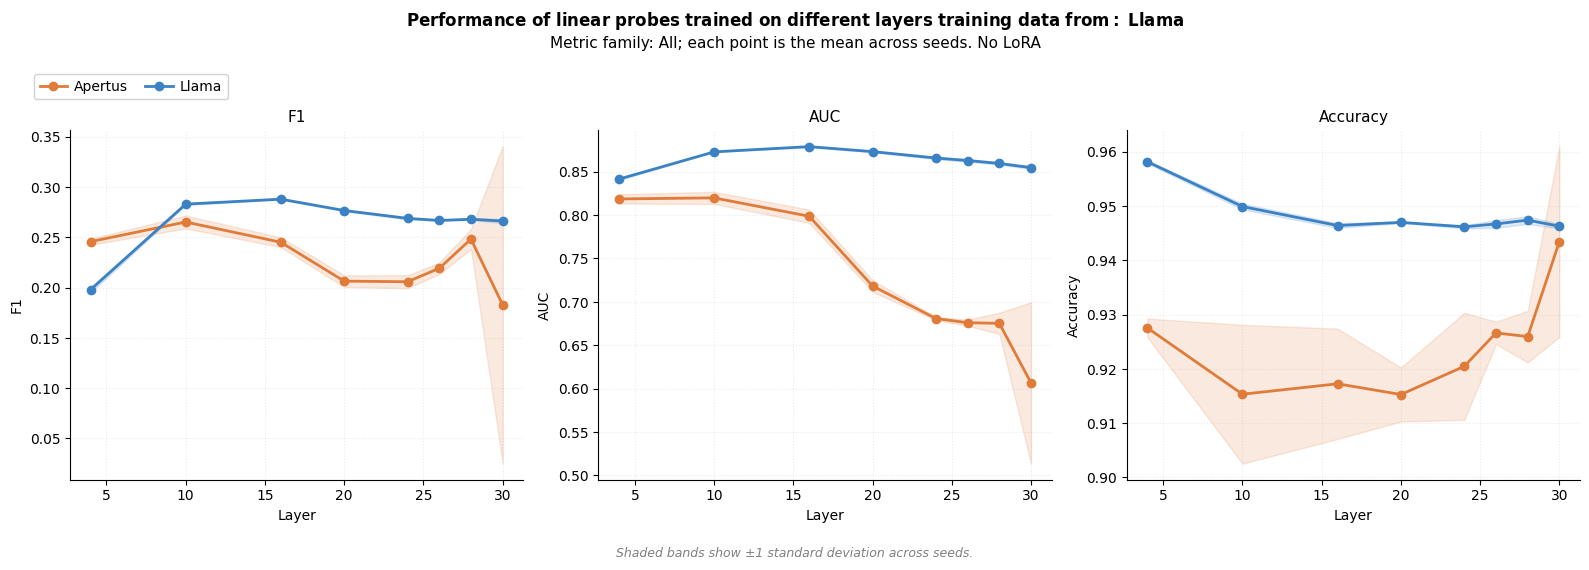

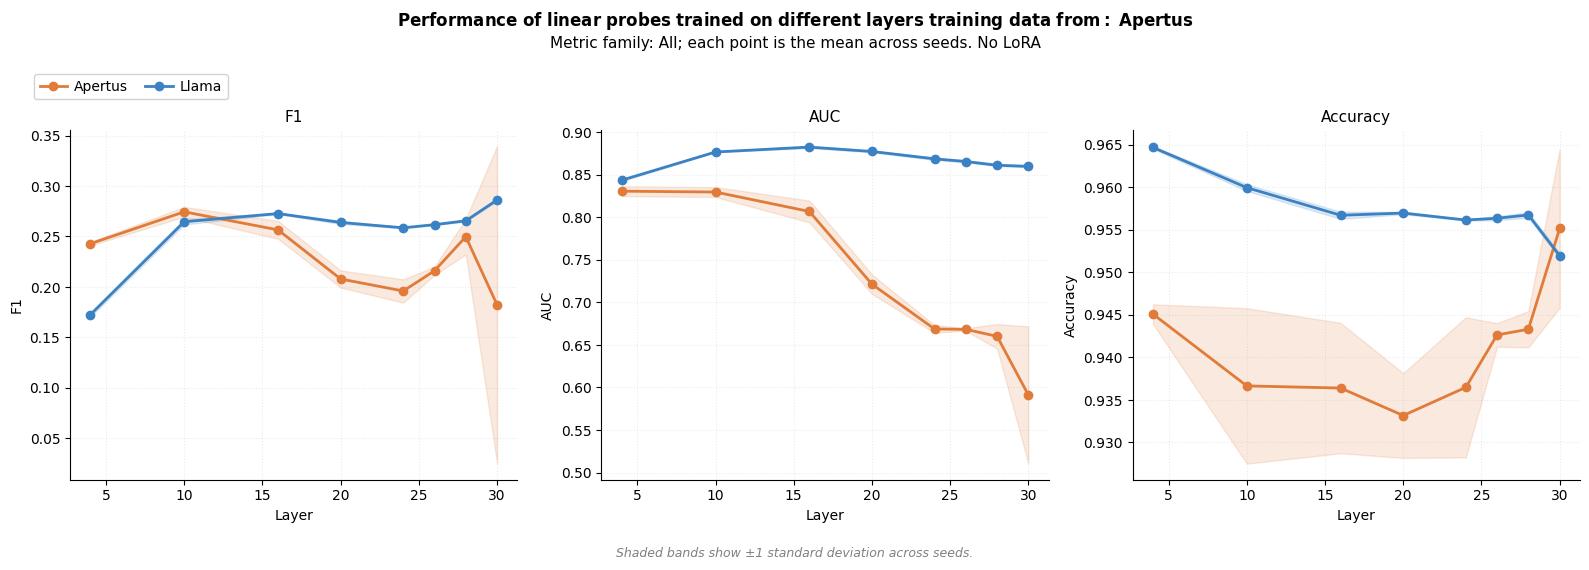

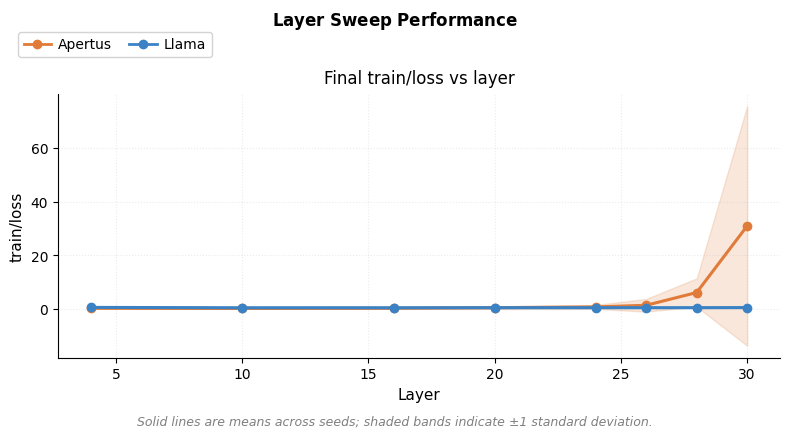

In [45]:
# Plot F1 / AUC / Accuracy vs layer (averaged across seeds, split by model)


plot_core_metrics_vs_layer(runs_df, eval_target="longfact_test_llama", family="span_max")
plot_core_metrics_vs_layer(runs_df, eval_target="longfact_test_apertus", family="span_max")


plot_core_metrics_vs_layer(runs_df, eval_target="longfact_test_llama", family="span")
plot_core_metrics_vs_layer(runs_df, eval_target="longfact_test_apertus", family="span")


plot_core_metrics_vs_layer(runs_df, eval_target="longfact_test_llama", family="all")
plot_core_metrics_vs_layer(runs_df, eval_target="longfact_test_apertus", family="all")

# Loss plot from local logs (final train/loss logged by W&B)
plot_loss_vs_layer(runs_df, loss_key="train/loss")

## Manual investigation dataframe

This section builds one consolidated dataframe with key metrics per run, plus helpful comparison columns (e.g., Llama minus Apertus metric gaps) and per-model ranking.

In [10]:
def build_manual_investigation_df(
    runs_df: pd.DataFrame,
    metric_families: tuple[str, ...] = ("span_max", "span", "all"),
    metric_names: tuple[str, ...] = ("f1", "auc", "accuracy"),
) -> pd.DataFrame:
    if runs_df.empty:
        return pd.DataFrame()

    base_cols = [
        "run_name", "run_id", "run_url", "model", "layer", "seed", "source_err",
    ]
    available_base_cols = [col for col in base_cols if col in runs_df.columns]
    out = runs_df[available_base_cols].copy()

    for eval_target in ("llama", "apertus"):
        for family in metric_families:
            for metric in metric_names:
                src = f"train/longfact_test_{eval_target}/{family}_{metric}"
                dst = f"{eval_target}_{family}_{metric}"
                out[dst] = runs_df[src] if src in runs_df.columns else np.nan

    out["train_loss_final"] = runs_df["train/loss"] if "train/loss" in runs_df.columns else np.nan

    for family in metric_families:
        for metric in metric_names:
            llama_col = f"llama_{family}_{metric}"
            apertus_col = f"apertus_{family}_{metric}"
            if llama_col in out.columns and apertus_col in out.columns:
                out[f"gap_{family}_{metric}_llama_minus_apertus"] = out[llama_col] - out[apertus_col]
                out[f"mean_{family}_{metric}_across_targets"] = out[[llama_col, apertus_col]].mean(axis=1)

    rank_metric = "llama_span_all_auc"
    if rank_metric in out.columns:
        out["rank_within_model_by_llama_span_all_auc"] = (
            out.groupby("model")[rank_metric]
            .rank(ascending=False, method="min")
            .astype("Int64")
        )

    sort_cols = [col for col in ["model", "layer", "seed"] if col in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    return out

In [11]:
manual_metrics_df = build_manual_investigation_df(runs_df)
print(f"manual_metrics_df shape: {manual_metrics_df.shape}")
display(manual_metrics_df)

# Optional export for external review
export_path = Path("exports/manual_metrics_df.csv")
export_path.parent.mkdir(parents=True, exist_ok=True)
manual_metrics_df.to_csv(export_path, index=False)
print(f"Saved: {export_path}")

print("\nTop 10 runs per model by llama span_max F1")
if "rank_within_model_by_llama_span_all_auc" in manual_metrics_df.columns:
    display(
        manual_metrics_df[manual_metrics_df["rank_within_model_by_llama_span_all_auc"] <= 10]
        .sort_values(["model", "rank_within_model_by_llama_span_all_auc", "layer", "seed"])
    )

manual_metrics_df shape: (48, 44)


,run_name,run_id,run_url,model,layer,seed,source_err,llama_span_max_f1,llama_span_max_auc,llama_span_max_accuracy,llama_span_f1,llama_span_auc,llama_span_accuracy,llama_all_f1,llama_all_auc,llama_all_accuracy,apertus_span_max_f1,apertus_span_max_auc,apertus_span_max_accuracy,apertus_span_f1,apertus_span_auc,apertus_span_accuracy,apertus_all_f1,apertus_all_auc,apertus_all_accuracy,train_loss_final,gap_span_max_f1_llama_minus_apertus,mean_span_max_f1_across_targets,gap_span_max_auc_llama_minus_apertus,mean_span_max_auc_across_targets,gap_span_max_accuracy_llama_minus_apertus,mean_span_max_accuracy_across_targets,gap_span_f1_llama_minus_apertus,mean_span_f1_across_targets,gap_span_auc_llama_minus_apertus,mean_span_auc_across_targets,gap_span_accuracy_llama_minus_apertus,mean_span_accuracy_across_targets,gap_all_f1_llama_minus_apertus,mean_all_f1_across_targets,gap_all_auc_llama_minus_apertus,mean_all_auc_across_targets,gap_all_accuracy_llama_minus_apertus,mean_all_accuracy_across_targets
0,apertus_no_lora_long_form_layer4_seed42,f1osa4x3,https://wandb.ai/ethz-lsai-25/hallucination-pr...,apertus,4,42,../clariden/log/even-layer-seeds-1593546_6.err,0.578584,0.811477,0.801053,0.449453,0.777610,0.704637,0.242230,0.813248,0.925942,0.545308,0.823438,0.817094,0.384168,0.782070,0.719577,0.240945,0.824844,0.943984,0.301314,0.033277,0.561946,-0.011961,0.817457,-0.016041,0.809073,0.065285,0.416811,-0.004461,0.779840,-0.014939,0.712107,0.001285,0.241588,-0.011597,0.819046,-0.018042,0.934963
1,apertus_no_lora_long_form_layer4_seed43,k9210t28,https://wandb.ai/ethz-lsai-25/hallucination-pr...,apertus,4,43,../clariden/log/even-layer-seeds-1593546_6.err,0.573342,0.807824,0.798197,0.443318,0.776085,0.703462,0.247099,0.823943,0.929356,0.547827,0.822353,0.817960,0.378177,0.781841,0.718922,0.244405,0.836407,0.946283,0.248202,0.025515,0.560585,-0.014530,0.815088,-0.019763,0.808079,0.065141,0.410748,-0.005756,0.778963,-0.015460,0.711192,0.002694,0.245752,-0.012465,0.830175,-0.016926,0.937820
2,apertus_no_lora_long_form_layer4_seed44,4dw0ohsb,https://wandb.ai/ethz-lsai-25/hallucination-pr...,apertus,4,44,../clariden/log/even-layer-seeds-1593546_6.err,0.573777,0.807481,0.798688,0.453365,0.777284,0.705969,0.247858,0.818772,0.927346,0.546221,0.821552,0.819206,0.383485,0.782909,0.720510,0.243102,0.830202,0.944983,0.148470,0.027556,0.559999,-0.014071,0.814516,-0.020518,0.808947,0.069880,0.418425,-0.005626,0.780097,-0.014541,0.713239,0.004756,0.245480,-0.011430,0.824487,-0.017636,0.936165
3,apertus_no_lora_long_form_layer10_seed42,2msk68xv,https://wandb.ai/ethz-lsai-25/hallucination-pr...,apertus,10,42,../clariden/log/even-layer-seeds-1593546_6.err,0.639567,0.857475,0.818811,0.493873,0.813953,0.723525,0.269753,0.825076,0.928298,0.625671,0.868249,0.841413,0.433227,0.823750,0.737887,0.271590,0.834979,0.945382,0.118864,0.013896,0.632619,-0.010774,0.862862,-0.022602,0.830112,0.060646,0.463550,-0.009796,0.818852,-0.014362,0.730706,-0.001836,0.270672,-0.009903,0.830028,-0.017084,0.936840
4,apertus_no_lora_long_form_layer10_seed43,ennpfi5c,https://wandb.ai/ethz-lsai-25/hallucination-pr...,apertus,10,43,../clariden/log/even-layer-seeds-1593549_7.err,0.650889,0.857727,0.815063,0.545862,0.818641,0.736033,0.268025,0.822618,0.914929,0.638392,0.868907,0.840221,0.490885,0.828808,0.751346,0.280137,0.830068,0.937379,0.289212,0.012497,0.644640,-0.011180,0.863317,-0.025158,0.827642,0.054977,0.518373,-0.010166,0.823724,-0.015313,0.743690,-0.012112,0.274081,-0.007450,0.826343,-0.022450,0.926154
5,apertus_no_lora_long_form_layer10_seed44,ckfvtpqq,https://wandb.ai/ethz-lsai-25/hallucination-pr...,apertus,10,44,../clariden/log/even-layer-seeds-1593549_7.err,0.658098,0.858686,0.810110,0.573266,0.817217,0.743727,0.257873,0.811921,0.902727,0.650844,0.870544,0.834263,0.523754,0.828562,0.756867,0.271690,0.823364,0.927144,0.141648,0.007253,0.654471,-0.011857,0.864615,-0.024153,0.822187,0.049511,0.548510,-0.011345,0.822890,-0.013141,0.750297,-0.013817,0.264781,-0.011444,0.817642,-0.024417,

Saved: exports/manual_metrics_df.csv

Top 10 runs per model by llama span_max F1


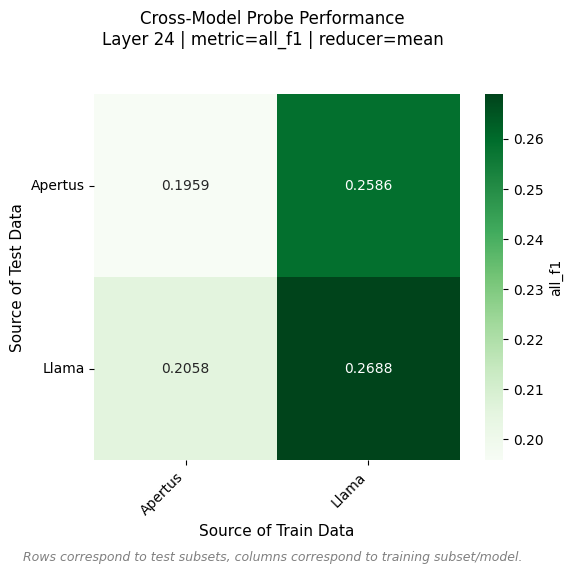

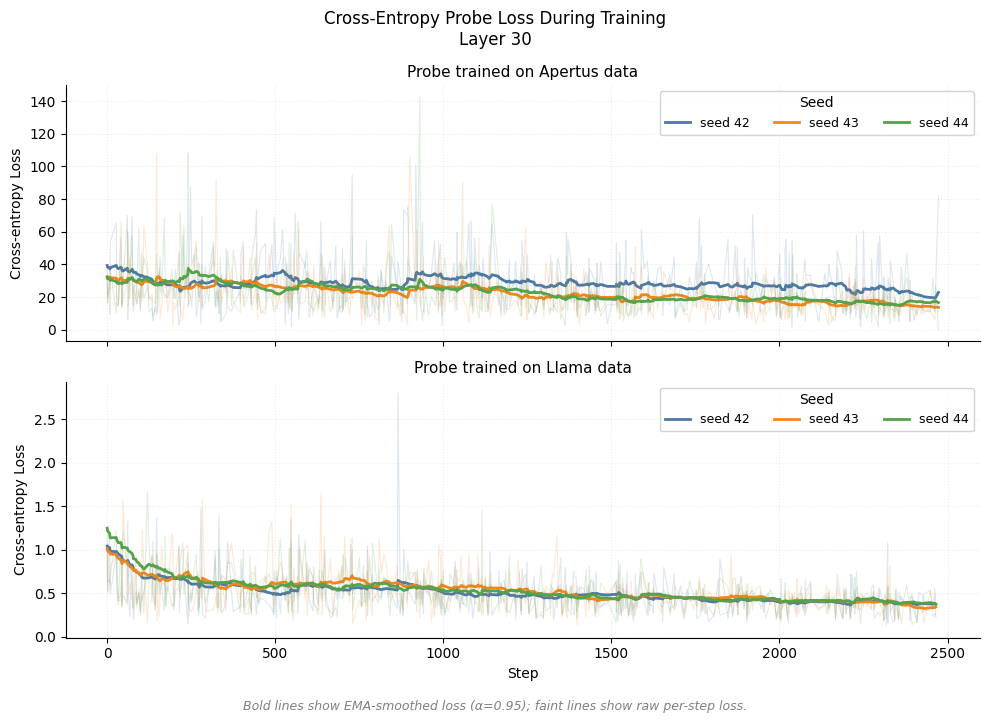

,_step,train/loss,run_id,run_name,model,layer,seed
0,0,32.523121,vhvivjkc,apertus_no_lora_long_form_layer30_seed43,apertus,30,43
1,1,16.261600,vhvivjkc,apertus_no_lora_long_form_layer30_seed43,apertus,30,43
2,7,33.913311,vhvivjkc,apertus_no_lora_long_form_layer30_seed43,apertus,30,43
3,8,38.524708,vhvivjkc,apertus_no_lora_long_form_layer30_seed43,apertus,30,43
4,9,25.274675,vhvivjkc,apertus_no_lora_long_form_layer30_seed43,apertus,30,43
...,...,...,...,...,...,...,...
2995,2430,0.485005,ojujrfsw,llama_no_lora_long_form_layer30_seed44,llama,30,44
2996,2449,0.538036,ojujrfsw,llama_no_lora_long_form_layer30_seed44,llama,30,44
2997,2457,0.227710,ojujrfsw,llama_no_lora_long_form_layer30_seed44,llama,30,44
2998,2462,0.274669,ojujrfsw,llama_no_lora_long_form_layer30_seed44,llama,30,44


In [41]:
def plot_layer_cross_model_heatmap(
    runs_df: pd.DataFrame,
    layer: int,
    metric: str = "f1",
    family: str = "all",
    reducer: str = "mean",
    cmap: str = "Greens",
):
    import seaborn as sns

    model_names = ["apertus", "llama"]
    metric_key = lambda eval_target: f"train/longfact_test_{eval_target}/{family}_{metric}"

    available_layers = sorted(runs_df["layer"].dropna().astype(int).unique().tolist())
    if layer not in available_layers:
        raise ValueError(f"Layer {layer} not found. Available layers: {available_layers}")

    layer_df = runs_df[runs_df["layer"] == layer]
    reduce_fn = np.mean if reducer == "mean" else np.median

    matrix = np.full((2, 2), np.nan, dtype=float)
    for row_idx, eval_target in enumerate(model_names):
        key = metric_key(eval_target)
        if key not in layer_df.columns:
            continue
        for col_idx, train_model in enumerate(model_names):
            values = layer_df[layer_df["model"] == train_model][key].dropna().values
            if len(values):
                matrix[row_idx, col_idx] = float(reduce_fn(values))

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".4f",
        cmap=cmap,
        xticklabels=["Apertus", "Llama"],
        yticklabels=["Apertus", "Llama"],
        cbar_kws={"label": f"{family}_{metric}"},
        square=True,
        ax=ax,
    )

    ax.set_xlabel("Source of Train Data", fontsize=11)
    ax.set_ylabel("Source of Test Data", fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    fig.suptitle(
        f"Cross-Model Probe Performance\nLayer {layer} | metric={family}_{metric} | reducer={reducer}",
        fontsize=12,
        y=1.03,
    )
    fig.text(
        0.5,
        -0.03,
        "Rows correspond to test subsets, columns correspond to training subset/model.",
        ha="center",
        fontsize=9,
        style="italic",
        color="gray",
    )
    fig.tight_layout()
    plt.show()

    return pd.DataFrame(matrix, index=["test_apertus", "test_llama"], columns=["train_apertus", "train_llama"] )


def plot_layer_loss_chart(
    runs_df: pd.DataFrame,
    layer: int,
    metric_key: str = "train/loss",
    ema_weight: float = 0.95,
    entity: str = "ethz-lsai-25",
    project: str = "hallucination-probes",
):
    layer_df = runs_df[runs_df["layer"] == layer].copy()
    if layer_df.empty:
        raise ValueError(f"No runs found for layer {layer}.")

    hist_df = fetch_wandb_loss_history(
        layer_df,
        entity=entity,
        project=project,
        metric_key=metric_key,
    )
    if hist_df.empty:
        print("No W&B history found for the selected layer.")
        return pd.DataFrame()

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    seed_palette = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756"]

    for ax, train_model in zip(axes, ["apertus", "llama"]):
        model_hist = hist_df[hist_df["model"] == train_model]
        if model_hist.empty:
            ax.set_title(f"Probe trained on {MODEL_LABELS.get(train_model, train_model)} data (missing)")
            _style_axis(ax)
            continue

        for idx, ((run_name, seed), run_df) in enumerate(model_hist.groupby(["run_name", "seed"])):
            run_df = run_df.sort_values("_step")
            x = run_df["_step"].to_numpy()
            y_raw = run_df[metric_key].to_numpy(dtype=float)
            y_smooth = _ema_smooth(y_raw, weight=ema_weight)
            color = seed_palette[idx % len(seed_palette)]

            ax.plot(x, y_raw, color=color, alpha=0.18, linewidth=0.8)
            ax.plot(x, y_smooth, color=color, linewidth=2.0, label=f"seed {seed}")

        _style_axis(ax)
        ax.set_title(f"Probe trained on {MODEL_LABELS.get(train_model, train_model)} data", fontsize=11, pad=6)
        ax.set_ylabel("Cross-entropy Loss", fontsize=10)
        ax.legend(loc="upper right", ncol=3, framealpha=0.85, fontsize=9, title="Seed")

    axes[-1].set_xlabel("Step", fontsize=10)
    fig.suptitle(
        f"Cross-Entropy Probe Loss During Training\nLayer {layer}",
        fontsize=12,
    )
    fig.text(
        0.5,
        -0.02,
        f"Bold lines show EMA-smoothed loss (α={ema_weight}); faint lines show raw per-step loss.",
        ha="center",
        fontsize=9,
        style="italic",
        color="gray",
    )
    fig.tight_layout()
    plt.show()

    return hist_df


# Example usage
plot_layer_cross_model_heatmap(runs_df, layer=24, metric="f1", family="all")
plot_layer_loss_chart(runs_df, layer=30)